# 🗺️ Embedding splitters: latent-space holdouts

Welcome! This notebook is a hands-on tour of chemsplit's **`embedding`** splitter family: three
splitters that all work the same way — reduce molecules to a low-dimensional numeric embedding
(UMAP, a linear/manifold projection, or a caller-supplied latent space), then split by clustering,
cutting an axis, or binning a grid *in that embedding*. The goal is to hold out a structurally or
topologically distant region of chemical space rather than a naive random split, which is a much
harder (and more realistic) generalisation test for a downstream model.

**Contents**
1. [🗺️ The embedding splitter family](#1)
   - [🌀 `UMAPClusterSplitter`](#1.1)
   - [📐 `ProjectionSplitter`](#1.2)
   - [🧭 `LatentSpaceSplitter`](#1.3)

<a id="1"></a>
## 1. 🗺️ The embedding splitter family

All three splitters share the same skeleton — embed, then group — so the same toy dataset works
for all of them: two chemically distant clusters of molecules (`make_two_clusters`), plus a plain
random 16-dimensional feature matrix to stand in for a precomputed descriptor/embedding block.

In [1]:
import numpy as np

from chemsplit.datasets import make_two_clusters
from chemsplit.splitters.embedding import (
    LatentSpaceSplitter,
    ProjectionSplitter,
    UMAPClusterSplitter,
)


def summarize(result):
    print(f"train={result.train.size}  valid={result.valid.size}  "
          f"test={result.test.size}  discard={result.discard.size}")
    return result

fx = make_two_clusters(n=200, seed=0)
smiles = fx.smiles
print(f"{len(smiles)} molecules in two chemically distant clusters")

rng = np.random.default_rng(0)
features = rng.standard_normal((len(smiles), 16))
print(f"features shape: {features.shape}")

200 molecules in two chemically distant clusters
features shape: (200, 16)


<a id="1.1"></a>
### 1.1 🌀 `UMAPClusterSplitter` (`umap_cluster`)

Embeds the featurized records into a low-dimensional UMAP space, then clusters that embedding and
treats each cluster as an atomic group — nearby points in the embedding always land on the same
side of the split.

| Parameter | Meaning |
|---|---|
| `train_size` / `test_size` | target fraction of records per partition |
| `random_state` | seed controlling the UMAP fit, the clustering, and the group assignment |
| `n_neighbors` | UMAP local-neighbourhood size; governs the local/global trade-off and materially changes the resulting split (default 15) |

> 💡 **Advantages**
> - Typically produces the widest train/test gap among routinely used splits — a strong stress test.
> - The embedding is directly plottable, so train and test regions are visible on one figure — something no fingerprint-space split offers.
> - Non-linear, so it separates chemical families that PCA blends together.
> - Scales to far larger datasets than spectral clustering.

> ⚠️ **Pitfalls**
> - **UMAP doesn't preserve global distances.** Inter-cluster distances in the embedding aren't meaningful, so "these clusters are far apart in UMAP" isn't evidence of dissimilarity. Verify with `audit.nn_similarity_profile` in fingerprint space.
> - The split shifts substantially with `n_neighbors`, `min_dist`, `n_components`, `densmap`, and the seed — all recorded in `params` and all must be reported.
> - Reproducibility depends on library versions, not just the seed: a `numba`/`pynndescent` upgrade can change the embedding and therefore the split.
> - Choosing the cluster count is guesswork, as in `k_means_cluster`, compounded here by the embedding's own hyperparameters.

In [2]:
umap_splitter = UMAPClusterSplitter(train_size=0.7, test_size=0.3, random_state=0, n_neighbors=10)
[umap_result] = umap_splitter.split_result(smiles)
summarize(umap_result)
print(f"n_clusters={umap_result.metadata['n_clusters']}  cluster_sizes={umap_result.metadata['cluster_sizes']}")

[03:46:57] Running LargestFragmentChooser
[03:46:57] Initializing Normalizer
[03:46:57] Running Normalizer
[03:46:57] Running Uncharger
[03:46:57] Running LargestFragmentChooser
[03:46:57] Initializing Normalizer
[03:46:57] Running Normalizer
[03:46:57] Running Uncharger
[03:46:57] Running LargestFragmentChooser
[03:46:57] Initializing Normalizer
[03:46:57] Running Normalizer
[03:46:57] Running Uncharger
[03:46:57] Running LargestFragmentChooser
[03:46:57] Initializing Normalizer
[03:46:57] Running Normalizer
[03:46:57] Running Uncharger
[03:46:57] Running LargestFragmentChooser
[03:46:57] Initializing Normalizer
[03:46:57] Running Normalizer
[03:46:57] Running Uncharger
[03:46:57] Running LargestFragmentChooser
[03:46:57] Initializing Normalizer
[03:46:57] Running Normalizer
[03:46:57] Running Uncharger
[03:46:57] Running LargestFragmentChooser
[03:46:57] Initializing Normalizer
[03:46:57] Running Normalizer
[03:46:57] Running Uncharger
[03:46:57] Running LargestFragmentChooser
[03:46

[03:46:58] Running Uncharger
[03:46:58] Running LargestFragmentChooser
[03:46:58] Initializing Normalizer
[03:46:58] Running Normalizer
[03:46:58] Running Uncharger
[03:46:58] Running LargestFragmentChooser
[03:46:58] Initializing Normalizer
[03:46:58] Running Normalizer
[03:46:58] Running Uncharger
[03:46:58] Running LargestFragmentChooser
[03:46:58] Initializing Normalizer
[03:46:58] Running Normalizer
[03:46:58] Running Uncharger
[03:46:58] Running LargestFragmentChooser
[03:46:58] Initializing Normalizer
[03:46:58] Running Normalizer
[03:46:58] Running Uncharger
[03:46:58] Running LargestFragmentChooser
[03:46:58] Initializing Normalizer
[03:46:58] Running Normalizer
[03:46:58] Running Uncharger
[03:46:58] Running LargestFragmentChooser
[03:46:58] Initializing Normalizer
[03:46:58] Running Normalizer
[03:46:58] Running Uncharger
[03:46:58] Running LargestFragmentChooser
[03:46:58] Initializing Normalizer
[03:46:58] Running Normalizer
[03:46:58] Running Uncharger
[03:46:58] Running 

[03:46:58] Running LargestFragmentChooser
[03:46:58] Initializing Normalizer
[03:46:58] Running Normalizer
[03:46:58] Running Uncharger
[03:46:58] Running LargestFragmentChooser
[03:46:58] Initializing Normalizer
[03:46:58] Running Normalizer
[03:46:58] Running Uncharger
[03:46:58] Running LargestFragmentChooser
[03:46:58] Initializing Normalizer
[03:46:58] Running Normalizer
[03:46:58] Running Uncharger
[03:46:58] Running LargestFragmentChooser
[03:46:58] Initializing Normalizer
[03:46:58] Running Normalizer
[03:46:58] Running Uncharger
[03:46:58] Running LargestFragmentChooser
[03:46:58] Initializing Normalizer
[03:46:58] Running Normalizer
[03:46:58] Running Uncharger
[03:46:58] Running LargestFragmentChooser
[03:46:58] Initializing Normalizer
[03:46:58] Running Normalizer
[03:46:58] Running Uncharger
[03:46:58] Running LargestFragmentChooser
[03:46:58] Initializing Normalizer
[03:46:58] Running Normalizer
[03:46:58] Running Uncharger
[03:46:58] Running LargestFragmentChooser
[03:46

/home/olivier/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/olivier/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(


train=140  valid=0  test=60  discard=0
n_clusters=14  cluster_sizes=[17, 7, 18, 15, 21, 12, 10, 14, 21, 17, 15, 9, 16, 8]


<a id="1.2"></a>
### 1.2 📐 `ProjectionSplitter` (`projection`)

Linear or manifold projection (PCA/SVD/kernel-PCA/t-SNE/MDS) of a feature matrix, then a split by
clustering in that projection (`mode="cluster"`), cutting along one axis (`mode="axis_cut"`), or
binning a grid over the first few components (`mode="grid"`).

| Parameter | Meaning |
|---|---|
| `method` | projection method, e.g. `"pca"` (linear, cheap, interpretable) |
| `mode` | `"cluster"` groups by projection cluster; `"axis_cut"` sorts by `axis` and cuts contiguous blocks; `"grid"` bins each axis into `grid_bins` equal-frequency bins |
| `n_components` | projected dimension |
| `axis` | component index used by `mode="axis_cut"` |
| `grid_bins` | bins per axis for `mode="grid"` |

> 💡 **Advantages**
> - PCA is linear, cheap, and interpretable — the loading vector shows *which* descriptors define the split direction, unlike any non-linear method.
> - `mode="axis_cut"` gives a clean, reportable one-dimensional extrapolation along the dataset's main axis of variation.
> - `explained_variance_ratio` states plainly how much of the data the projection actually captured — an honesty check UMAP and t-SNE lack.

> ⚠️ **Pitfalls**
> - **t-SNE inter-cluster distances are meaningless.** Treating t-SNE geometry as a split criterion attributes chemical significance to an artefact of its cost function.
> - PCA on binary fingerprints puts most variance in bit frequency, which correlates with molecule size, so the first component often just tracks "how big is the molecule".
> - `mode="grid"` produces exponentially many groups, most empty or singletons.
> - Two components typically explain only a small fraction of fingerprint variance — check `explained_variance_ratio` before trusting the geometry.

In [3]:
proj_cluster = ProjectionSplitter(
    method="pca", mode="cluster", n_components=3, train_size=0.7, test_size=0.3, random_state=0,
)
[proj_cluster_result] = proj_cluster.split_result(features, X_kind="features")
summarize(proj_cluster_result)
print(f"method={proj_cluster_result.metadata['method']}  mode={proj_cluster_result.metadata['mode']}")

proj_axis = ProjectionSplitter(
    method="pca", mode="axis_cut", axis=0, n_components=2, train_size=0.7, test_size=0.3, random_state=0,
)
[proj_axis_result] = proj_axis.split_result(features, X_kind="features")
summarize(proj_axis_result)
print(f"mode={proj_axis_result.metadata['mode']}")

proj_grid = ProjectionSplitter(
    method="pca", mode="grid", n_components=2, grid_bins=3, train_size=0.7, test_size=0.3, random_state=0,
)
[proj_grid_result] = proj_grid.split_result(features, X_kind="features")
summarize(proj_grid_result)
print(f"mode={proj_grid_result.metadata['mode']}")

train=139  valid=0  test=61  discard=0
method=pca  mode=cluster
train=140  valid=0  test=60  discard=0
mode=axis_cut
train=140  valid=0  test=60  discard=0
mode=grid


A picture is worth a thousand `metadata` fields — here's the `cluster` mode's train/test assignment projected onto its own first two principal components:

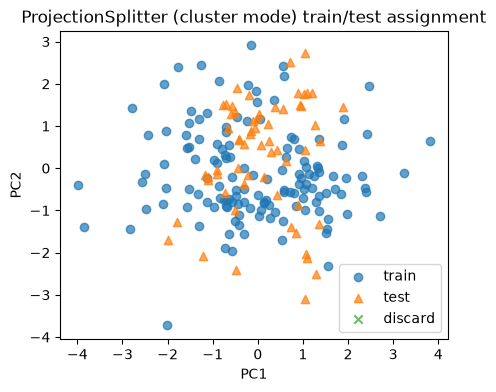

In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

coords = PCA(n_components=2, random_state=0).fit_transform(features)
colors = np.full(len(smiles), "discard")
colors[proj_cluster_result.train] = "train"
colors[proj_cluster_result.test] = "test"

fig, ax = plt.subplots(figsize=(5, 4))
for label, marker in [("train", "o"), ("test", "^"), ("discard", "x")]:
    mask = colors == label
    ax.scatter(coords[mask, 0], coords[mask, 1], label=label, alpha=0.7, marker=marker)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("ProjectionSplitter (cluster mode) train/test assignment")
ax.legend()
plt.show()

<a id="1.3"></a>
### 1.3 🧭 `LatentSpaceSplitter` (`latent_space`)

Clusters directly in an embedding *supplied by the caller* — e.g. a ChemBERTa/GNN/VAE latent
space computed outside chemsplit — instead of computing one internally.

| Parameter | Meaning |
|---|---|
| `embedding` | an `(n, d)` array, or a callable applied to `X` |
| `normalize` | row normalisation applied to the embedding before clustering (default `"l2"`) |
| `independence_declared` | set `True` once you've confirmed the embedding model wasn't fit on data that includes your test set, to silence the circularity warning |

> 💡 **Advantages**
> - Splits in the space the downstream model actually perceives — arguably the most relevant notion of "similar" for that model.
> - Works for modalities without fingerprints: reaction embeddings, 3-D conformer embeddings, multimodal representations.
> - `embedding_hash` ties the split to a specific representation, making it traceable.

> ⚠️ **Pitfalls**
> - **Circularity.** If the encoder defining the split is also the model under evaluation, or was pretrained on the same data, the split is inadvertently tuned to be easy or hard for that model. Use an independent encoder — `independence_declared` forces you to think about this, but doesn't verify it.
> - Pretrained encoders usually saw enormous public corpora overlapping your test set, so novelty relative to your training set isn't novelty relative to the encoder's pretraining set.
> - Latent geometry drifts with checkpoint, tokenizer, and pooling choices, so a split reproduces only against a pinned encoder artefact.
> - Cosine distance in a latent space has no chemical units, so fingerprint-space cutoff intuitions don't transfer.

In [5]:
def toy_encoder(raw_features):
    # stand-in for an external embedding model (e.g. a pretrained molecular encoder)
    rng = np.random.default_rng(1)
    return rng.standard_normal((raw_features.shape[0], 4))

latent_splitter = LatentSpaceSplitter(
    embedding=toy_encoder, train_size=0.7, test_size=0.3, random_state=0, independence_declared=True,
)
[latent_result] = latent_splitter.split_result(features, X_kind="features")
summarize(latent_result)
print(f"embedding_dim={latent_result.metadata['embedding_dim']}")

train=140  valid=0  test=60  discard=0
embedding_dim=4


That's the whole family: pick an embedding — UMAP, a linear/manifold projection, or your own
model's latent space — then group by cluster, axis, or grid inside it. See `notebooks/similarity.ipynb`
for the fingerprint-space analogues of the same idea.